# Classificação de tumores cerebrais em ressonâncias magnéticas com uma CNN

## Qual é o objetivo?

Treinar uma **rede neural convolucional (CNN)** que recebe uma imagem de ressonância magnética (RM) do cérebro e responde em qual de **quatro categorias** ela se encaixa:

| Classe | O que significa |
|---|---|
| **Glioma** | tumor que se origina nas células de sustentação do próprio tecido cerebral |
| **Meningioma** | tumor que se origina nas meninges, as membranas que envolvem o cérebro |
| **Pituitária** | tumor na hipófise (glândula na base do cérebro) |
| **Sem tumor** | exame sem lesão tumoral |

Mas o objetivo não é só "acertar bastante". Vamos também **entender como o modelo decide, onde ele erra e quanto podemos confiar nele**. Por isso o notebook dedica quase tanto espaço a perguntas incômodas (as imagens são mesmo diferentes? o modelo olha para o tumor?) quanto ao treino em si.

> **Aviso importante:** este é um projeto **educacional**. O modelo não é uma ferramenta de diagnóstico e nada aqui substitui a avaliação de um profissional de saúde.

## Mapa do notebook

| Etapa | Pergunta que ela responde |
|---|---|
| 1. Os dados | O que exatamente vamos classificar? |
| 2. Limpeza | As imagens do dataset são realmente todas diferentes? |
| 3. Divisão treino / validação / teste | Como separar os dados sem que o modelo "cole" na prova? |
| 4. Explorando | Como são as imagens? Os grupos são equilibrados? |
| 5. O que é uma CNN | Como uma rede aprende a "enxergar"? |
| 6. Treino | Como o modelo aprende, e quando paramos? |
| 7. Avaliação | Quão bom ele é, e em que tipo de erro? |
| 8. Grad-CAM | Para onde a rede olha quando decide? |
| 9. Robustez | O que acontece se mexermos no fundo da imagem? |
| 10. Demo | O modelo funcionando em imagens novas |
| 11. Limitações | O que este modelo ainda **não** garante |

**Requisitos:** o treino fica bem mais rápido com GPU (no Colab: *Ambiente de execução → Alterar tipo de ambiente*), e o download dos dados pede credenciais do Kaggle.

In [ ]:
%pip install -q imagehash kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
import json, hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import kagglehub
import imagehash
from scipy.sparse import csr_matrix
from IPython.display import HTML, display
from scipy.sparse.csgraph import connected_components

import tensorflow as tf
from tensorflow.keras import layers

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, f1_score, recall_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

## 1. Os dados

Usamos o dataset público **Brain Tumor Classification (MRI)**, do Kaggle (`sartajbhuvaji/brain-tumor-classification-mri`). Ele traz imagens de ressonância organizadas em pastas `Training` e `Testing`, com uma subpasta por classe.

**O que fazemos ao carregar cada imagem:**

- **Tons de cinza (1 canal):** ressonâncias não têm cor, então 1 canal basta e deixa o modelo menor.
- **Redimensionar para 80 x 80 pixels:** todas as imagens precisam ter o mesmo tamanho para entrar na rede. Imagens pequenas treinam mais rápido, ao custo de perder detalhes finos.
- **Rótulo numérico por pasta:** a pasta (ex.: `glioma_tumor`) vira um número de 0 a 3. A ordem alfabética dos nomes define qual número é qual classe.

Depois do carregamento, cada imagem é só uma **matriz 80 x 80 de números** entre 0 (preto) e 255 (branco). É isso que a rede enxerga.

In [ ]:
TREINAR = True  #  False (pula download e treino)
DATASET = "sartajbhuvaji/brain-tumor-classification-mri"
IMG_SIZE = (80, 80)
EXTS = {".png", ".jpg", ".jpeg"}

if TREINAR:
    root = Path(kagglehub.dataset_download(DATASET))  # reaproveita o cache se já baixou
    train_dir = next(root.rglob("Training"))
    test_dir = next(root.rglob("Testing"))

    class_names = sorted(p.name for p in train_dir.iterdir() if p.is_dir())
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    num_classes = len(class_names)

    def load_split(split_dir):
        x, y = [], []
        for class_name in class_names:
            for path in sorted((split_dir / class_name).iterdir()):
                if path.suffix.lower() in EXTS:
                    img = Image.open(path).convert("L").resize(IMG_SIZE)
                    x.append(np.array(img))
                    y.append(class_to_idx[class_name])
        return np.expand_dims(np.array(x), -1), np.array(y)

    x_train_full, y_train_full = load_split(train_dir)
    x_test, y_test = load_split(test_dir)

    with open("class_names.json", "w") as f:
        json.dump(class_names, f)  # a demo final lê daqui

    print(class_names)
    print("Treino:", x_train_full.shape, "| Teste:", x_test.shape)
    print("Imagens por classe (treino):", np.bincount(y_train_full))

100%|██████████| 86.8M/86.8M [00:01<00:00, 75.1MB/s]

Extracting files...


['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Treino: (2870, 80, 80, 1) | Teste: (394, 80, 80, 1)
Imagens por classe (treino): [826 822 395 827]


## 2. Limpeza: o dataset tem imagens repetidas?

Antes de treinar qualquer coisa, precisamos garantir que o modelo será avaliado de forma **honesta**.

**O problema do vazamento de dados (*data leakage*).** Imagine uma prova em que algumas questões são idênticas às do exercício que o aluno estudou. A nota alta não prova que ele aprendeu a matéria, só que ele decorou. Com modelos acontece o mesmo: se a mesma imagem aparece no treino e no teste, a acurácia sai inflada porque o modelo está *reconhecendo*, e não *generalizando*.

**Como detectamos repetições exatas:** calculamos um **hash MD5** de cada imagem, uma "impressão digital" dos pixels. Duas imagens com o mesmo hash são idênticas pixel a pixel. Então:

1. Dentro do treino, mantemos só a primeira ocorrência de cada imagem.
2. Do conjunto de teste original do Kaggle, removemos tudo que já existe no treino.
3. Juntamos o que sobrou em um **pool único** de imagens exclusivas.

O resultado é revelador: do conjunto de teste original, só **101 de 394** imagens não existiam no treino. Se tivéssemos usado a divisão original, a maior parte do "teste" seria memorização.

In [ ]:
import hashlib

def img_hash(img):
    return hashlib.md5(img.tobytes()).hexdigest()

h_train = np.array([img_hash(i) for i in x_train_full])
h_test = np.array([img_hash(i) for i in x_test])

# treino: mantém só a primeira ocorrência de cada imagem
_, first_idx = np.unique(h_train, return_index=True)
first_idx = np.sort(first_idx)
x_train_full, y_train_full, h_train = x_train_full[first_idx], y_train_full[first_idx], h_train[first_idx]

# teste: remove duplicatas internas e o que já está no treino
_, first_t = np.unique(h_test, return_index=True)
keep = np.zeros(len(h_test), dtype=bool)
keep[first_t] = True
keep &= ~np.isin(h_test, h_train)
x_test, y_test = x_test[keep], y_test[keep]

# pool único de imagens exclusivas
x_pool = np.concatenate([x_train_full, x_test])
y_pool = np.concatenate([y_train_full, y_test])
assert len({img_hash(i) for i in x_pool}) == len(x_pool), "ainda há duplicatas no pool"
print("Pool:", x_pool.shape, "| por classe:", np.bincount(y_pool))


Pool: (2870, 80, 80, 1) | por classe: [886 823 327 834]


In [ ]:
sns.set_theme(style="white", rc={
    "figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#555", "axes.labelcolor": "#333", "text.color": "#222",
})

NOMES = {"glioma_tumor": "Glioma", "meningioma_tumor": "Meningioma",
         "no_tumor": "Sem tumor", "pituitary_tumor": "Pituitária"}
nomes = [NOMES.get(c, c) for c in class_names]

cores = ["#2A9D8F", "#E76F51", "#E9C46A", "#6D597A"]

CMAP_MAT = "crest"      # matrizes de confusão
CMAP_CAM = "inferno"    # Grad-CAM

## 3. Quase-duplicatas e a divisão em treino, validação e teste

O hash MD5 só encontra cópias **idênticas**. Uma foto recomprimida, levemente deslocada ou com brilho diferente passa despercebida, e ainda assim é "a mesma imagem" para o modelo.

**Hash perceptual (`phash`).** Em vez de olhar os bytes, ele resume a *aparência* da imagem em 64 bits. Imagens parecidas geram hashes parecidos, e medimos a diferença pela **distância de Hamming** (quantos bits diferem). Aqui, distância **≤ 4** significa "quase a mesma imagem".

**Grupos.** Ligamos as imagens quase iguais e formamos **grupos** (componentes conectados). Cada grupo é tratado como uma unidade: ele inteiro vai para treino, **ou** para validação, **ou** para teste, nunca dividido entre eles. A divisão (`StratifiedGroupKFold`) também mantém a proporção de cada classe nos três conjuntos.

**Para que serve cada conjunto:**

| Conjunto | Proporção | Papel |
|---|---|---|
| **Treino** | ~70% | O modelo aprende com ele (ajusta seus pesos). |
| **Validação** | ~15% | Acompanha o progresso durante o treino e decide quando parar e qual versão guardar. |
| **Teste** | ~15% | Prova final. É usado **uma vez**, só no fim, para medir o desempenho real. |

> **Limitação honesta:** o dataset não informa de qual paciente é cada imagem. Cortes diferentes do mesmo paciente podem cair em conjuntos diferentes, o que deixa as métricas um pouco otimistas. O ideal seria dividir por paciente.

A célula seguinte salva os conjuntos prontos em disco, para não precisar refazer toda esta preparação se a sessão reiniciar.

In [ ]:
ph = np.array([imagehash.phash(Image.fromarray(i[..., 0])).hash.flatten() for i in x_pool])

# liga imagens com distância de Hamming <= THRESH
THRESH = 4
rows, cols = [], []
for i in range(len(ph)):
    d = (ph[i] != ph[i + 1:]).sum(1)
    j = np.where(d <= THRESH)[0] + i + 1
    rows += [i] * len(j)
    cols += j.tolist()
adj = csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(ph), len(ph)))
n_groups, groups = connected_components(adj, directed=False)

sizes = np.bincount(groups)
print(f"{len(ph)} imagens -> {n_groups} grupos | maior grupo: {sizes.max()} imagens")
conf = sum(len(set(y_pool[groups == g])) > 1 for g in np.where(sizes > 1)[0])
print("Grupos com classes misturadas:", conf)

# divisão ~70/15/15 respeitando os grupos e as classes
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)
tmp_idx, test_idx = next(sgkf.split(x_pool, y_pool, groups))
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=42)
tr, va = next(sgkf2.split(x_pool[tmp_idx], y_pool[tmp_idx], groups[tmp_idx]))
train_idx, val_idx = tmp_idx[tr], tmp_idx[va]

x_train, y_train = x_pool[train_idx], y_pool[train_idx]
x_val, y_val = x_pool[val_idx], y_pool[val_idx]
x_test, y_test = x_pool[test_idx], y_pool[test_idx]

for nome, y in [("Treino", y_train), ("Validação", y_val), ("Teste", y_test)]:
    print(f"{nome}: {len(y)} | por classe: {np.bincount(y, minlength=num_classes)}")

2870 imagens -> 2369 grupos | maior grupo: 9 imagens
Grupos com classes misturadas: 9
Treino: 2050 | por classe: [625 588 235 602]
Validação: 412 | por classe: [136 119  44 113]
Teste: 408 | por classe: [125 116  48 119]


## 4. Explorando as imagens

Antes de modelar, vale **olhar** os dados. Duas perguntas:

- **Os grupos são equilibrados?** A classe "Sem tumor" tem bem menos imagens que as outras. Isso importa: com poucos exemplos, o modelo tem menos chances de aprender bem essa classe, e a acurácia geral pode esconder um desempenho pior nela. Por isso vamos olhar métricas **por classe** na avaliação.
- **As imagens são homogêneas?** Repare que o dataset mistura cortes em **planos diferentes** (axial, sagital e coronal), com enquadramentos e contrastes variados. Isso torna a tarefa mais difícil e é um dos motivos de o modelo errar.

In [ ]:
np.savez_compressed(
    "splits.npz",
    x_train=x_train, y_train=y_train,
    x_val=x_val, y_val=y_val,
    x_test=x_test, y_test=y_test,
    x_pool=x_pool, y_pool=y_pool, groups=groups,
)

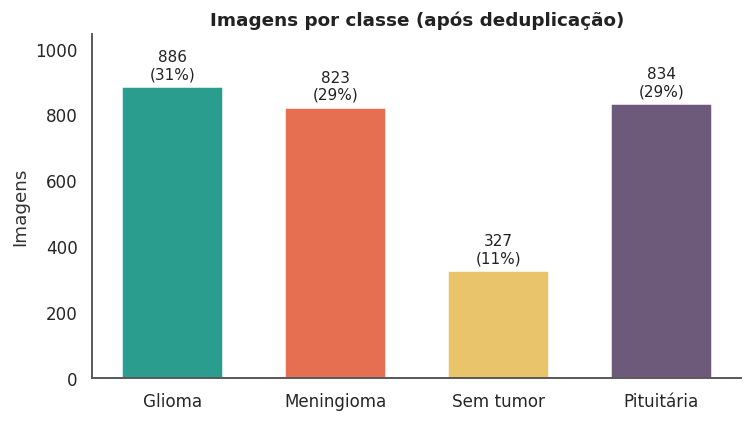

In [ ]:
 def mostrar_amostras(x, y, n=5, seed=0):
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(len(nomes), n, figsize=(2 * n, 2 * len(nomes)))
    for c in range(len(nomes)):
        idx = rng.choice(np.where(y == c)[0], n, replace=False)
        for j, i in enumerate(idx):
            ax = axes[c, j]
            ax.imshow(x[i, ..., 0], cmap="gray")
            ax.axis("off")
            if j == 0:
                ax.set_title(nomes[c], loc="left", fontsize=10, color=cores[c])
    plt.tight_layout()
    plt.show()
cont = np.bincount(y_pool)
fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(nomes, cont, color=cores, width=0.62, edgecolor="white")
for b, v in zip(barras, cont):
    ax.text(b.get_x() + b.get_width() / 2, v + 15, f"{v}\n({v / cont.sum():.0%})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, cont.max() * 1.18)
ax.set_ylabel("Imagens")
ax.set_title("Imagens por classe (após deduplicação)")
ax.grid(axis="x", visible=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


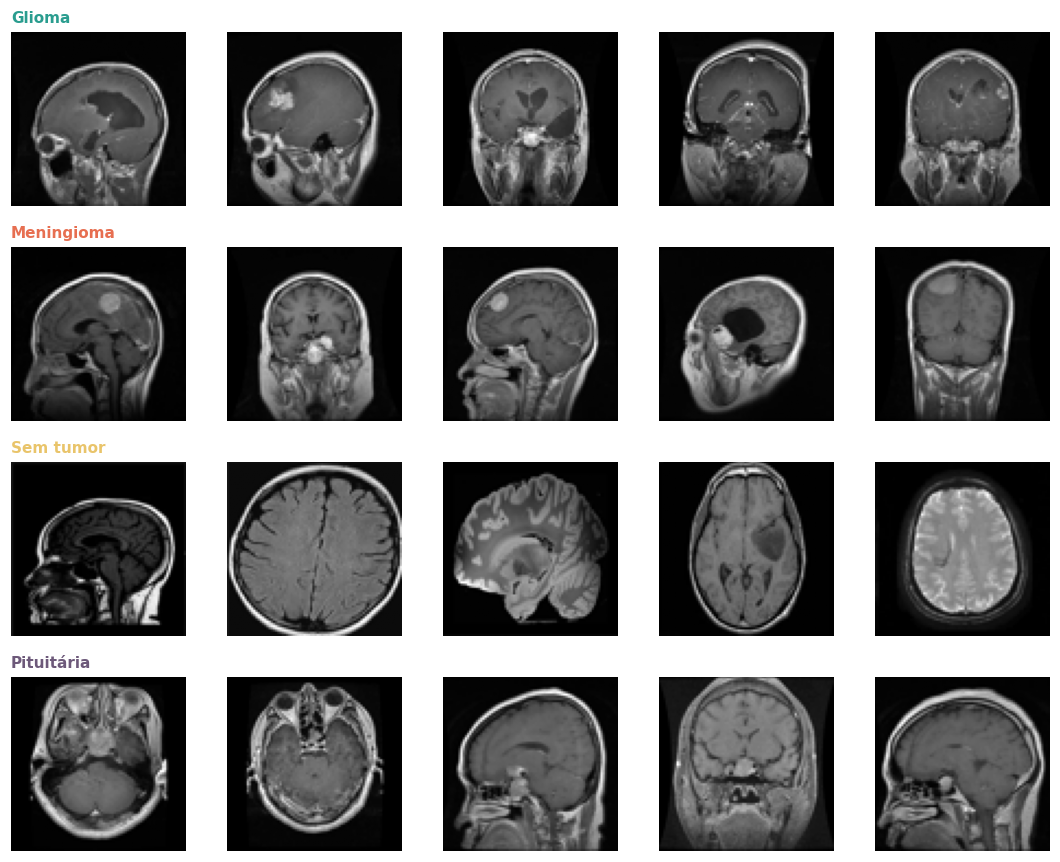

In [ ]:

mostrar_amostras(x_pool, y_pool)

## 5. O que é uma CNN e como ela "enxerga"?

Uma **CNN (Rede Neural Convolucional)** é um tipo de rede neural criada para trabalhar com imagens. A ideia central é simples: em uma imagem, **pixels vizinhos importam juntos**. Um conjunto de pixels claros formando um contorno é uma borda; várias bordas formam uma forma; várias formas formam um objeto. A CNN aprende essa hierarquia sozinha, do simples ao complexo.

### Por que não usar uma rede "comum"?

Uma rede totalmente conectada trataria os 6400 pixels como uma lista sem ordem, ignorando quem é vizinho de quem, e precisaria de milhões de parâmetros. A CNN usa **filtros pequenos que deslizam pela imagem**, reaproveitando os mesmos pesos em todas as posições. Fica mais enxuta e reconhece um padrão onde quer que ele apareça.

### Os blocos de construção

| Peça | O que faz | Em uma frase |
|---|---|---|
| **Convolução** (`Conv2D`) | Um filtro pequeno desliza pela imagem. Em cada posição, multiplica os pixels pelos números do filtro e soma. O resultado é um **mapa** que "acende" onde o padrão do filtro aparece. | Uma lupa que procura um padrão específico. |
| **ReLU** | Zera os valores negativos e mantém os positivos. | Só passa adiante o que "acendeu". |
| **Max Pooling** | Divide o mapa em quadradinhos de 2 x 2 e guarda só o **maior** valor de cada um. O mapa encolhe pela metade. | Resumir um parágrafo pela frase mais forte. |
| **Batch Normalization** | Reequilibra os valores no meio da rede. | Manter a régua calibrada, para o treino ficar estável. |
| **Dropout** | No treino, "desliga" ao acaso uma pequena fração dos neurônios. | Estudar sem poder depender sempre das mesmas anotações, para não decorar. |
| **Flatten** | Transforma os mapas em uma lista de números. | Esticar tudo em uma fila. |
| **Dense** | Cada neurônio combina todos os números da lista. | O júri que junta todas as pistas. |
| **Softmax** | Converte as 4 saídas em probabilidades que somam 100%. | O placar final de cada classe. |

**Sobre os filtros do nosso modelo:** cada filtro é uma janelinha de 2 x 2, ou seja, 4 números. **Esses números não são escolhidos por nós: são aprendidos no treino.** Cada camada usa vários filtros (64, 32, 16 e 8), e cada um acaba procurando um padrão diferente.

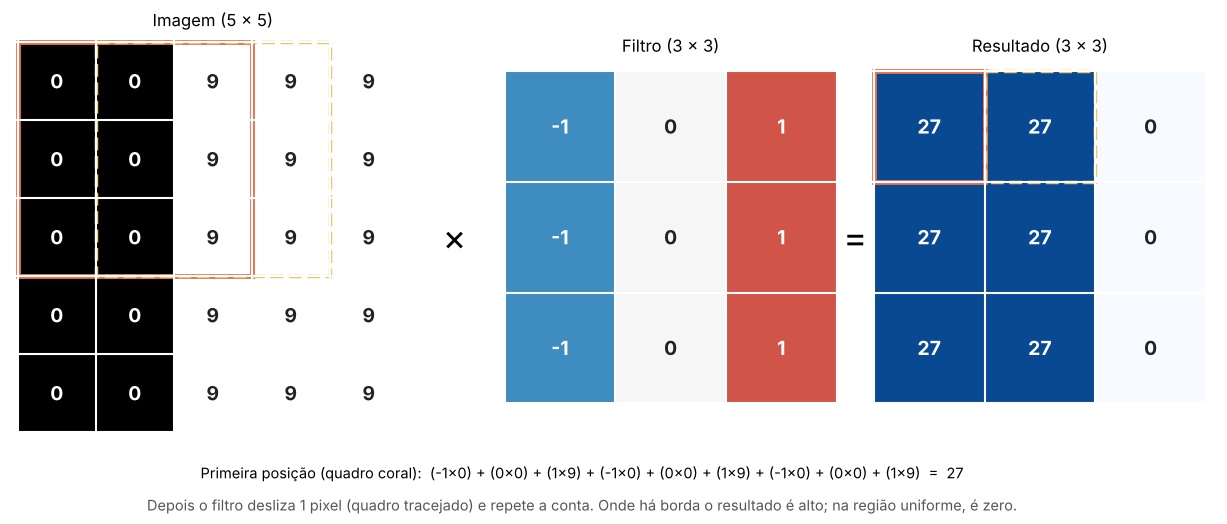


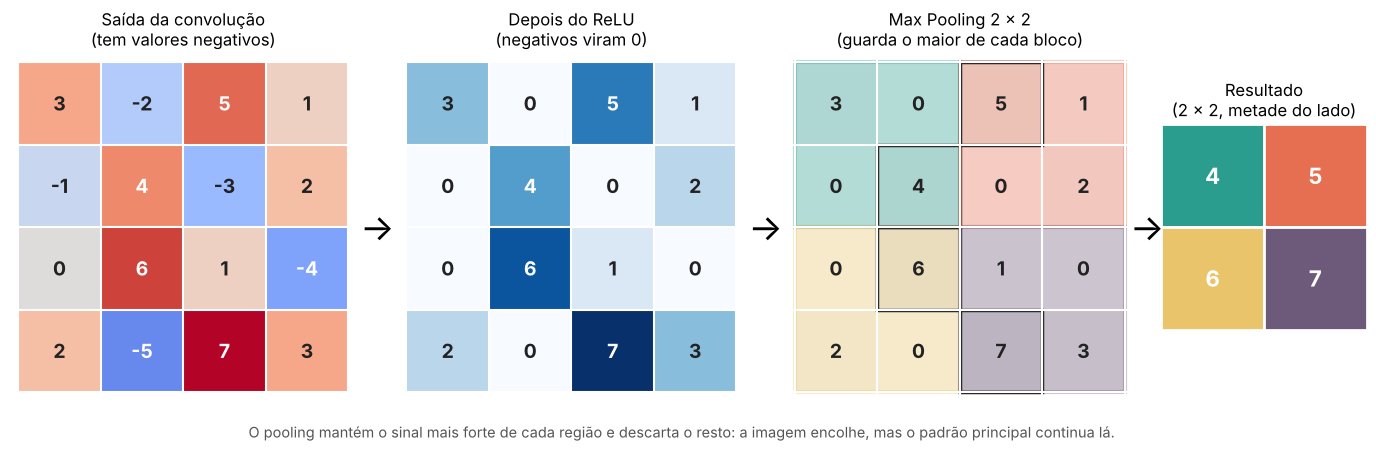


### A arquitetura deste modelo
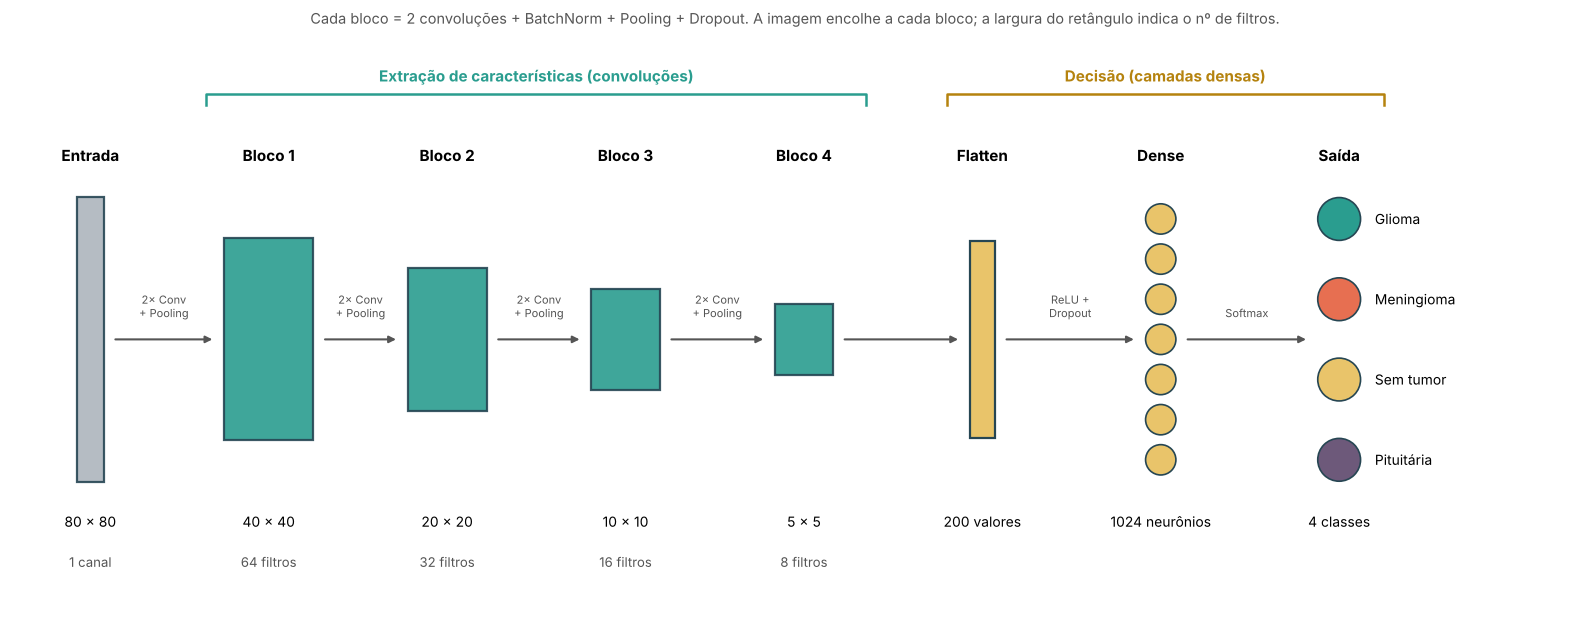


A cada bloco a imagem **encolhe** (80, 40, 20, 10, 5) enquanto a rede extrai características cada vez mais abstratas. No fim sobram 200 números, e a camada final transforma esses números em **4 probabilidades**, uma para cada classe.

**Curiosidade:** o modelo tem cerca de 243 mil parâmetros, e aproximadamente 85% deles estão na camada Dense de 1024 neurônios. As convoluções são baratas. (Confira com `model.summary()`.)

### Como a rede aprende?

1. **Prevê:** recebe um lote de 32 imagens e estima as probabilidades de cada classe.
2. **Mede o erro:** a função de perda (*cross-entropy*) compara a previsão com a classe real e pune mais quando o modelo erra com muita confiança.
3. **Ajusta:** a retropropagação calcula quanto cada peso contribuiu para o erro, e o otimizador **Adam** corrige todos os pesos um pouquinho na direção que reduz o erro.
4. **Repete:** passar por todas as imagens uma vez é uma **época**. O treino repete isso por muitas épocas.

É como um aluno que resolve exercícios, confere o gabarito e corrige o raciocínio, repetidas vezes.

## Aumento de dados (*data augmentation*)

Temos poucas imagens para uma rede com tantos parâmetros, e ela pode acabar **decorando** o treino (*overfitting*). Para dificultar, a cada época mostramos versões **ligeiramente alteradas** das mesmas imagens:

- **Espelhamento horizontal:** um tumor pode estar em qualquer lado do cérebro. Não espelhamos na vertical, porque uma cabeça de cabeça para baixo não existe na prática.
- **Rotação leve** (até cerca de 18 graus) e **zoom** (até 10%): simulam pequenas diferenças de posicionamento do paciente.

Essas camadas fazem parte do modelo, mas **só atuam durante o treino**. Na validação, no teste e na demo, a imagem entra como está. As variações são geradas na hora, a cada época, sem criar arquivos. Abaixo, uma imagem original e algumas versões possíveis dela:

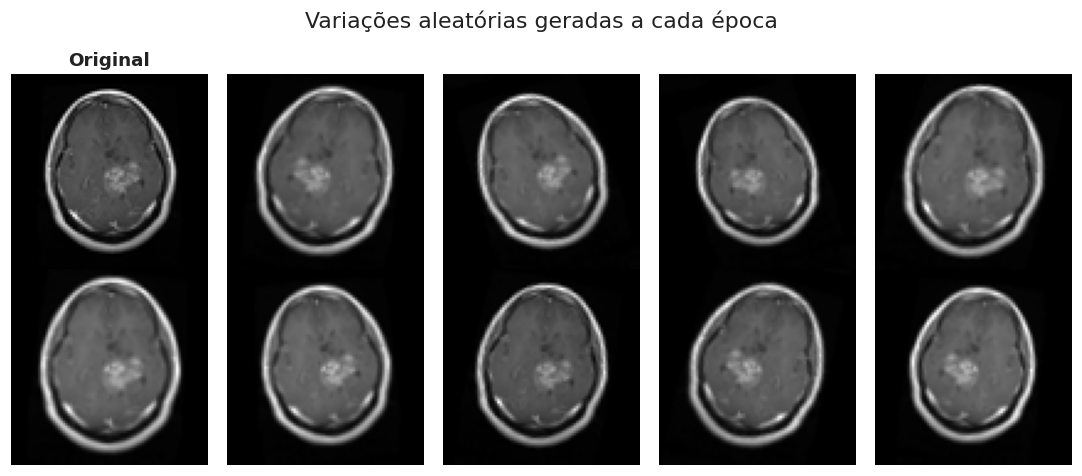

In [ ]:
aug = tf.keras.Sequential([layers.RandomFlip("horizontal"),
                           layers.RandomRotation(0.05),
                           layers.RandomZoom(0.1)])
img = x_train[0:1].astype("float32")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
axes[0, 0].imshow(x_train[0, ..., 0], cmap="gray")
axes[0, 0].set_title("Original")
for ax in axes.flat[1:]:
    ax.imshow(aug(img, training=True)[0, ..., 0], cmap="gray")
for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Variações aleatórias geradas a cada época")
plt.tight_layout()
plt.show()

## 6. Treinando o modelo

Aqui as peças se juntam: construímos a rede e treinamos por até **100 épocas**, com dois "assistentes" (*callbacks*):

- **`ModelCheckpoint`:** depois de cada época, olha a acurácia na **validação** e, se for a melhor até agora, salva o modelo. Assim guardamos a melhor versão, e não a última.
- **`EarlyStopping`:** se a acurácia de validação não melhorar por 15 épocas seguidas, o treino para e restaura os melhores pesos. Evita gastar tempo e piorar por *overfitting*.

O treino usa só as imagens de **treino**; a **validação** serve apenas para acompanhar. O conjunto de **teste não é tocado aqui**.

> **Dica de leitura:** na saída abaixo, compare `accuracy` (treino) com `val_accuracy` (validação). Se a primeira sobe e a segunda fica para trás, o modelo está decorando.

In [ ]:
def build_model(num_classes):
    def block(f):
        return [
            layers.Conv2D(f, (2, 2), activation="relu", padding="same"),
            layers.BatchNormalization(),
            layers.Conv2D(f, (2, 2), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.1),
        ]

    model = tf.keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 1)),
        layers.Rescaling(1.0 / 255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        *block(64), *block(32), *block(16), *block(8),
        layers.Flatten(),
        layers.Dense(1024, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

MODEL_PATH = "best_model.keras"
HISTORY_PATH = "history.json"

if TREINAR:
    model = build_model(num_classes)
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    ]
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=100, batch_size=32, callbacks=callbacks,
    ).history
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)
else:
    model = tf.keras.models.load_model(MODEL_PATH)
    with open(HISTORY_PATH) as f:
        history = json.load(f)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.5039 - loss: 1.1524 - val_accuracy: 0.2743 - val_loss: 1.3864
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5595 - loss: 1.0139 - val_accuracy: 0.2743 - val_loss: 2.0105
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6059 - loss: 0.9299 - val_accuracy: 0.2743 - val_loss: 2.8147
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6088 - loss: 0.9119 - val_accuracy: 0.2743 - val_loss: 3.2421
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6361 - loss: 0.8629 - val_accuracy: 0.2743 - val_loss: 3.0228
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6624 - loss: 0.8005 - val_accuracy: 0.2743 - val_loss: 2.6184
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6712 - loss: 0.7658 - val_accuracy: 0.2767 - val_loss: 2.7192
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6922 - loss: 0.7426 - val_accuracy: 0

## 7. Avaliando o modelo

### Lendo as curvas de treino

Os gráficos mostram, época a época, a **acurácia** e a **perda** no treino e na validação. Procure por:

- **Treino melhorando e validação acompanhando:** o modelo está aprendendo algo que generaliza.
- **Treino muito acima da validação:** *overfitting*, o modelo decora.
- **Validação oscilando muito:** o treino é instável (comum com poucos dados e taxa de aprendizado constante).
- A **linha pontilhada** marca a melhor época, que é a versão guardada.

In [ ]:
def plot_history(h):
    best = int(np.argmax(h["val_accuracy"]))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    for a, k, t in [(ax[0], "accuracy", "Acurácia"), (ax[1], "loss", "Perda")]:
        a.plot(h[k], color="tab:blue", label="Treino")
        a.plot(h["val_" + k], color="tab:orange", alpha=0.85, label="Validação")
        a.axvline(best, color="gray", ls=":", label=f"Melhor época ({best + 1})")
        a.set_title(t)
        a.set_xlabel("Época")
        a.legend()
    plt.tight_layout()
    plt.show()

def plot_confusao(y, pred):
    cm = confusion_matrix(y, pred)
    cmn = cm / cm.sum(1, keepdims=True)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=nomes, yticklabels=nomes, ax=ax[0])
    ax[0].set_title("Contagens")
    sns.heatmap(cmn, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=nomes, yticklabels=nomes, ax=ax[1])
    ax[1].set_title("% de cada classe real (recall)")
    for a in ax:
        a.set_xlabel("Predito")
        a.set_ylabel("Real")
    plt.tight_layout()
    plt.show()

def plot_roc(y, probs):
    y_bin = label_binarize(y, classes=range(len(nomes)))
    plt.figure(figsize=(7, 6))
    for i, nome in enumerate(nomes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, color=cores[i], lw=2, label=f"{nome} (AUC = {auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Acaso")
    plt.xlabel("Taxa de falsos positivos")
    plt.ylabel("Taxa de verdadeiros positivos")
    plt.title("Curva ROC por classe (teste)")
    plt.legend(loc="lower right")
    plt.show()

def avaliar(model, x, y):
    probs = model.predict(x, verbose=0)
    pred = probs.argmax(1)
    print(classification_report(y, pred, target_names=nomes, digits=3))
    plot_confusao(y, pred)
    plot_roc(y, probs)
    return pred


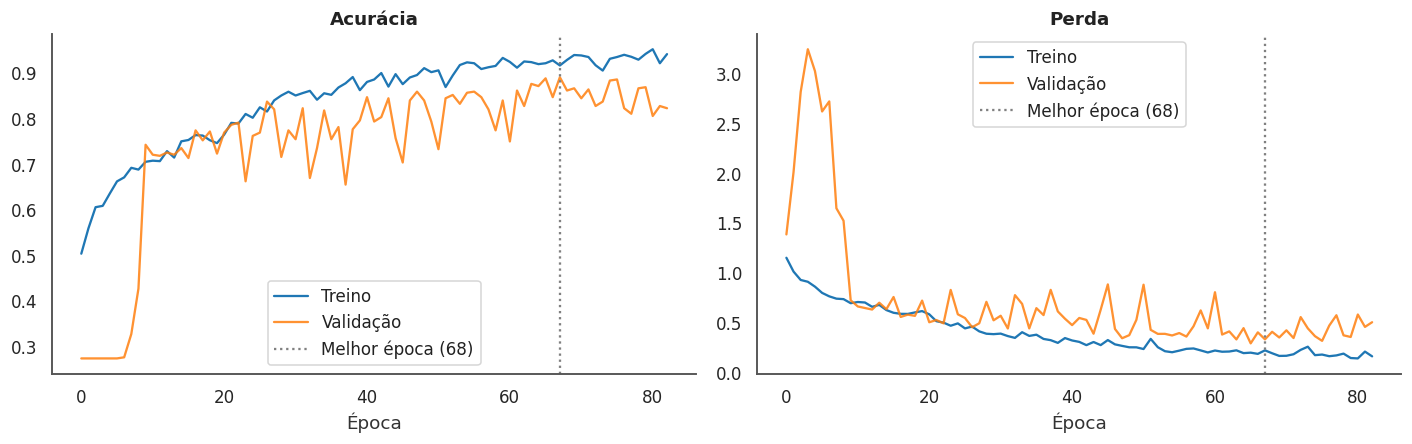

In [ ]:
plot_history(history)

### Avaliação final no conjunto de teste

Agora, e só agora, usamos o **teste**: imagens que o modelo nunca viu, nem para treinar nem para decidir quando parar. Cada medida responde a uma pergunta diferente:

| Métrica | Pergunta que responde |
|---|---|
| **Acurácia** | De todas as imagens, quantas ele acertou? |
| **Precisão** (de uma classe) | Quando ele diz "é meningioma", quantas vezes está certo? |
| **Recall** (de uma classe) | De todos os meningiomas reais, quantos ele encontrou? |
| **F1** | Um equilíbrio entre precisão e recall. |

**Matriz de confusão:** cada linha é a classe real e cada coluna é a classe prevista. A diagonal são os acertos; fora dela, os erros, que mostram **quais classes o modelo confunde**. O painel da direita normaliza por linha, ou seja, mostra o recall de cada classe.

**Curva ROC e AUC:** mostram a capacidade de separar cada classe das demais, para todos os limiares de decisão possíveis. Quanto mais a curva encosta no canto superior esquerdo (AUC perto de 1), melhor.

> **Atenção ao erro mais grave:** em saúde, os erros não pesam igual. Classificar um **tumor como "sem tumor"** é pior do que o contrário. Por isso olhamos o recall das classes de tumor e a linha "Sem tumor" da matriz, e não só a acurácia geral.

              precision    recall  f1-score   support

      Glioma      0.927     0.816     0.868       125
  Meningioma      0.868     0.793     0.829       116
   Sem tumor      0.719     0.854     0.781        48
  Pituitária      0.867     0.983     0.921       119

    accuracy                          0.863       408
   macro avg      0.845     0.862     0.850       408
weighted avg      0.868     0.863     0.862       408



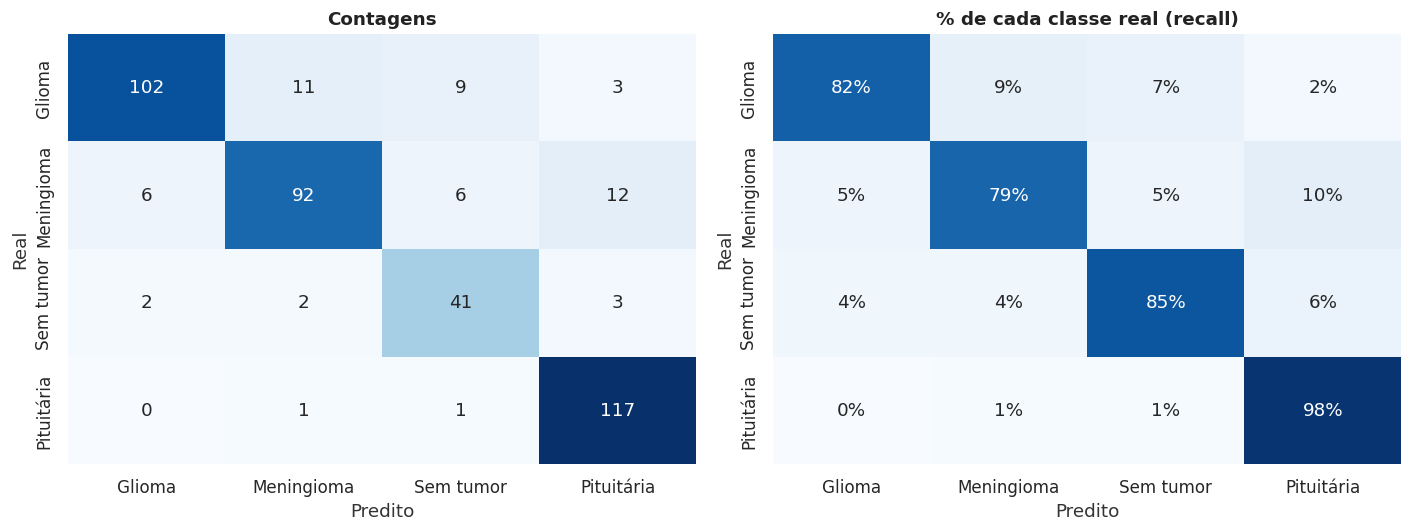

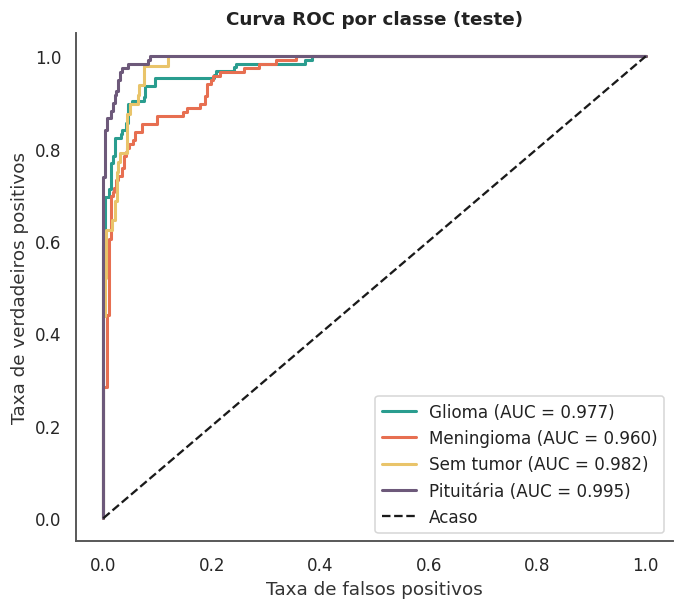

In [ ]:
pred_test = avaliar(model, x_test, y_test)

## 8. Para onde a rede olha? (Grad-CAM)

Um modelo pode acertar pelo motivo errado. Para investigar, usamos o **Grad-CAM**: uma técnica que mostra quais regiões da imagem **mais influenciaram** a decisão da rede.

**Como funciona, em resumo:** pegamos a última camada convolucional, calculamos o quanto cada mapa de características contribuiu para a classe escolhida e juntamos tudo em um **mapa de calor**. As regiões em tons mais quentes (amarelo/laranja) foram as mais importantes.

**Como ler as figuras:**

- **Esquerda:** a imagem real, com a classe verdadeira.
- **Centro:** o mapa de calor sobre a imagem, com a classe prevista e a confiança (verde = acerto, vermelho = erro).
- **Direita:** o contorno da região de maior atenção.

> **Cuidados importantes:**
> - **Isto não é segmentação.** O dataset não tem máscaras do tumor, e a rede só classifica. O mapa é grosseiro (a última camada convolucional tem 10 x 10 posições).
> - **Confiança alta não garante que a rede olhou para a lesão.** Um mapa fora do tumor, ou fora da cabeça, é um sinal de alerta de que o modelo pode estar usando outras pistas.
> - Os exemplos mostrados foram **selecionados** entre os acertos de maior confiança. Veja também os erros.

In [ ]:

def gradcam(model, img):
    """img: (80, 80, 1) uint8. Retorna mapa 80x80 em [0,1], probabilidades e classe prevista."""
    conv_idx = max(i for i, l in enumerate(model.layers) if isinstance(l, layers.Conv2D))
    x = tf.convert_to_tensor(img[None].astype("float32"))

    with tf.GradientTape() as tape:
        h = x
        for i, layer in enumerate(model.layers):
            h = layer(h, training=False)
            if i == conv_idx:
                conv_out = h
        preds = h
        pred = int(tf.argmax(preds[0]))
        score = preds[:, pred]

    grads = tape.gradient(score, conv_out)
    pesos = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.nn.relu(tf.reduce_sum(conv_out * pesos[:, None, None, :], axis=-1))[0].numpy()
    cam = cam / (cam.max() + 1e-8)
    cam = np.array(Image.fromarray((cam * 255).astype("uint8")).resize(IMG_SIZE, Image.BILINEAR)) / 255.0
    return cam, preds[0].numpy(), pred

probs_test = model.predict(x_test, verbose=0)
conf = probs_test.max(1)

In [ ]:
probs_test = model.predict(x_test, verbose=0)
conf = probs_test.max(1)

def melhores_acertos(k=1):
    """Os k acertos de maior confiança de cada classe."""
    idx = []
    for c in range(len(nomes)):
        cand = np.where((y_test == c) & (pred_test == c))[0]
        idx.extend(cand[np.argsort(-conf[cand], kind="stable")][:k])
    return idx

def dentro_da_cabeca(i):
    cam, _, _ = gradcam(model, x_test[i])
    cabeca = x_test[i, ..., 0] > 25   # limiar de intensidade, ajuste se precisar
    return (cam * cabeca).sum() / (cam.sum() + 1e-8)

def acertos_com_mapa_limpo(topo=15):
    idx = []
    for c in range(len(nomes)):
        cand = np.where((y_test == c) & (pred_test == c))[0]
        cand = cand[np.argsort(-conf[cand], kind="stable")][:topo]
        idx.append(max(cand, key=dentro_da_cabeca))
    return idx


In [ ]:


def mostrar_gradcam(model, x, y, indices, limiar=0.35):
    fundo = "#0F1115"
    fig, axes = plt.subplots(len(indices), 3, figsize=(9.5, 3.1 * len(indices)), squeeze=False)
    fig.patch.set_facecolor(fundo)
    for r, i in enumerate(indices):
        img = x[i, ..., 0]
        cam, probs, pred = gradcam(model, x[i])
        ok = pred == y[i]

        axes[r, 0].imshow(img, cmap="gray")
        axes[r, 0].set_title(f"Real: {nomes[y[i]]}", color="white", fontsize=11)

        axes[r, 1].imshow(img, cmap="gray")
        axes[r, 1].imshow(np.ma.masked_less(cam, limiar), cmap=CMAP_CAM, alpha=0.7, vmin=0, vmax=1)
        axes[r, 1].set_title(f"{'✓' if ok else '✗'} Previsto: {nomes[pred]} ({probs[pred]:.0%})",
                             color="#7EE0B5" if ok else "#FF8C7A", fontsize=11)

        axes[r, 2].imshow(img, cmap="gray")
        axes[r, 2].contour(cam, levels=[0.6], colors="#00E5FF", linewidths=1.8)
        axes[r, 2].set_title("Região de maior atenção", color="white", fontsize=11)

        for a in axes[r]:
            a.axis("off")
    plt.tight_layout()
    plt.show()

# um acerto de cada classe
acertos = [np.where((y_test == c) & (pred_test == c))[0][0] for c in range(len(nomes))]


Glioma -> índices (de cima para baixo): [88, 9]


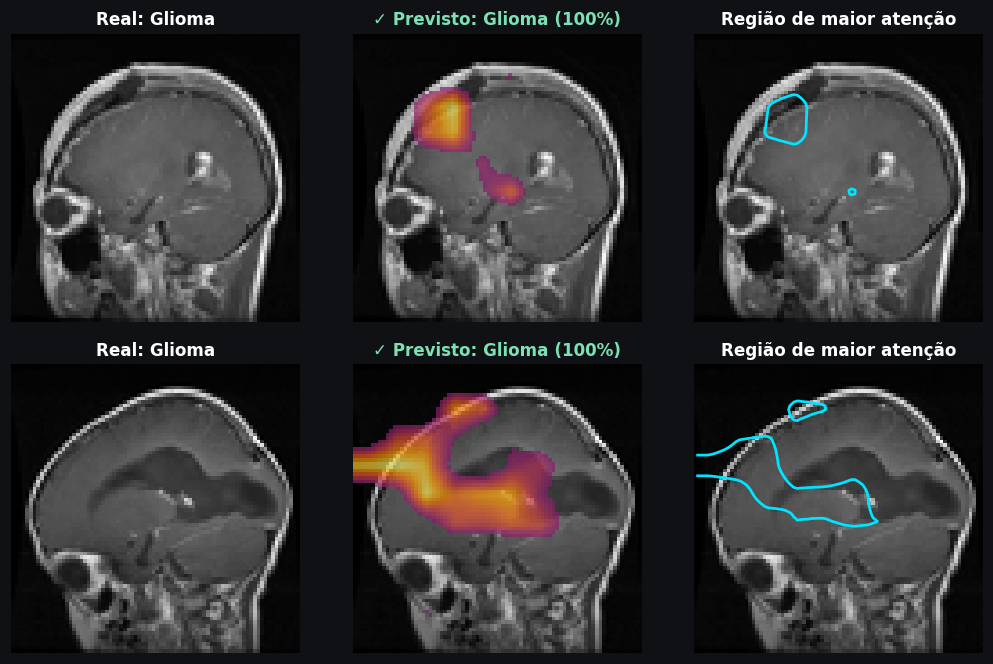

Meningioma -> índices (de cima para baixo): [199, 158]


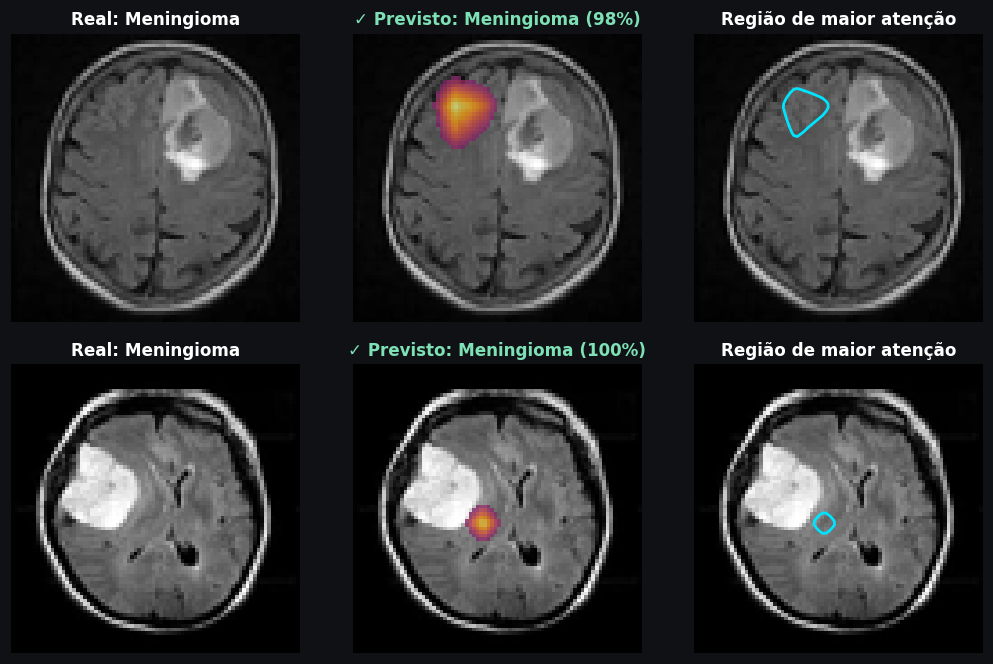

Sem tumor -> índices (de cima para baixo): [270, 263]


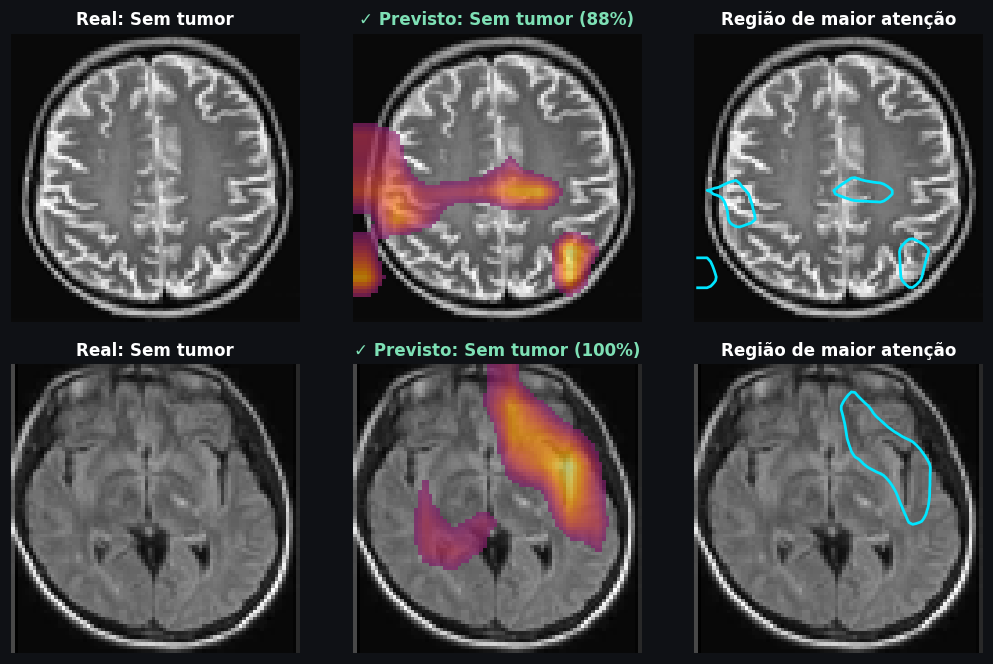

Pituitária -> índices (de cima para baixo): [296, 284]


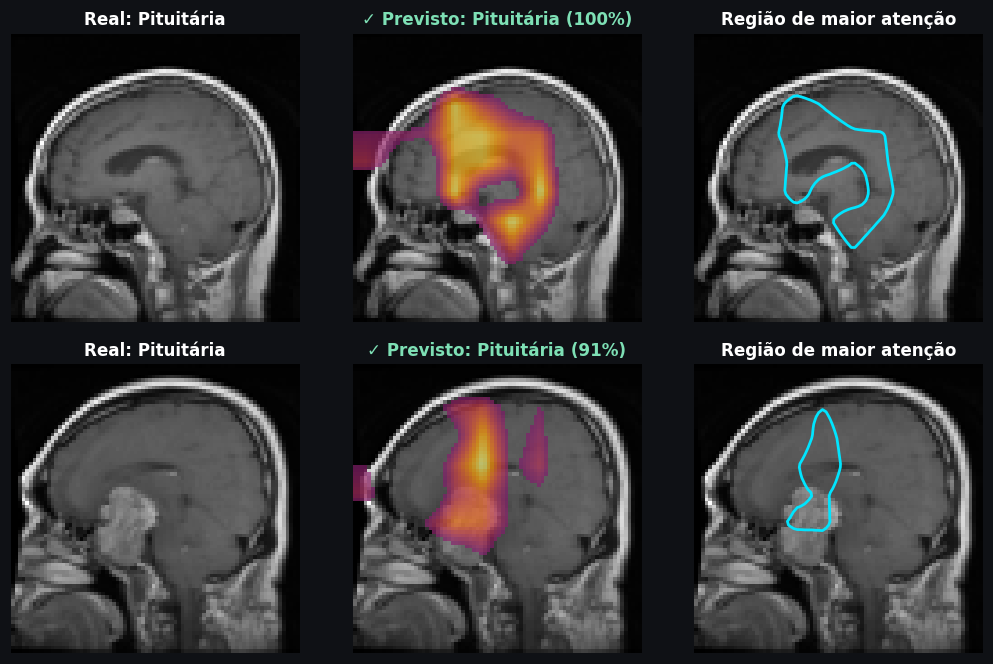

In [ ]:
def candidatos(c, k=2, conf_min=0.80, max_avaliar=100):
    cand = np.where((y_test == c) & (pred_test == c) & (conf >= conf_min))[0][:max_avaliar]
    pontos = {i: dentro_da_cabeca(i) for i in cand}
    return sorted(cand, key=lambda i: -pontos[i])[:k]

for c in range(len(nomes)):
    idx = candidatos(c)
    print(f"{nomes[c]} -> índices (de cima para baixo): {[int(i) for i in idx]}")
    mostrar_gradcam(model, x_test, y_test, idx)

In [ ]:
from scipy import ndimage as ndi

def mascara_cabeca(img):
    m = img[..., 0] > 25                       # limiar de intensidade, ajuste se precisar
    m = ndi.binary_closing(m, iterations=2)
    m = ndi.binary_fill_holes(m)
    lab, n = ndi.label(m)
    if n > 1:                                  # mantém só o maior objeto (a cabeça)
        tam = ndi.sum(m, lab, range(1, n + 1))
        m = lab == (np.argmax(tam) + 1)
    return m

# 1) nos exemplos escolhidos
def teste_fundo(indices):
    for i in indices:
        img = x_test[i]
        img2 = (img * mascara_cabeca(img)[..., None]).astype("uint8")
        p1 = model.predict(img[None], verbose=0)[0]
        p2 = model.predict(img2[None], verbose=0)[0]
        print(f"idx {i}: original -> {nomes[p1.argmax()]} ({p1.max():.0%}) | "
              f"fundo zerado -> {nomes[p2.argmax()]} ({p2.max():.0%})")

# 2) no teste inteiro
x_test_masc = np.stack([img * mascara_cabeca(img)[..., None] for img in x_test]).astype("uint8")
acc_orig = (pred_test == y_test).mean()
acc_masc = (model.predict(x_test_masc, verbose=0).argmax(1) == y_test).mean()
print(f"Acurácia original: {acc_orig:.1%} | com o fundo zerado: {acc_masc:.1%}")

Acurácia original: 86.3% | com o fundo zerado: 71.3%


In [ ]:
p_orig = model.predict(x_test, verbose=0).argmax(1)
p_masc = model.predict(x_test_masc, verbose=0).argmax(1)

print(f"Original: {(p_orig == y_test).mean():.1%} | Fundo zerado: {(p_masc == y_test).mean():.1%}")
print(f"Previsões que mudaram: {(p_orig != p_masc).sum()} de {len(y_test)}")

for c in range(len(nomes)):
    m = y_test == c
    print(f"{nomes[c]:<11} recall original {(p_orig[m] == c).mean():.1%} -> fundo zerado {(p_masc[m] == c).mean():.1%}")

Original: 86.3% | Fundo zerado: 71.3%
Previsões que mudaram: 87 de 408
Glioma      recall original 81.6% -> fundo zerado 76.0%
Meningioma  recall original 79.3% -> fundo zerado 60.3%
Sem tumor   recall original 85.4% -> fundo zerado 87.5%
Pituitária  recall original 98.3% -> fundo zerado 70.6%


23 meningiomas certos no original e errados com o fundo zerado


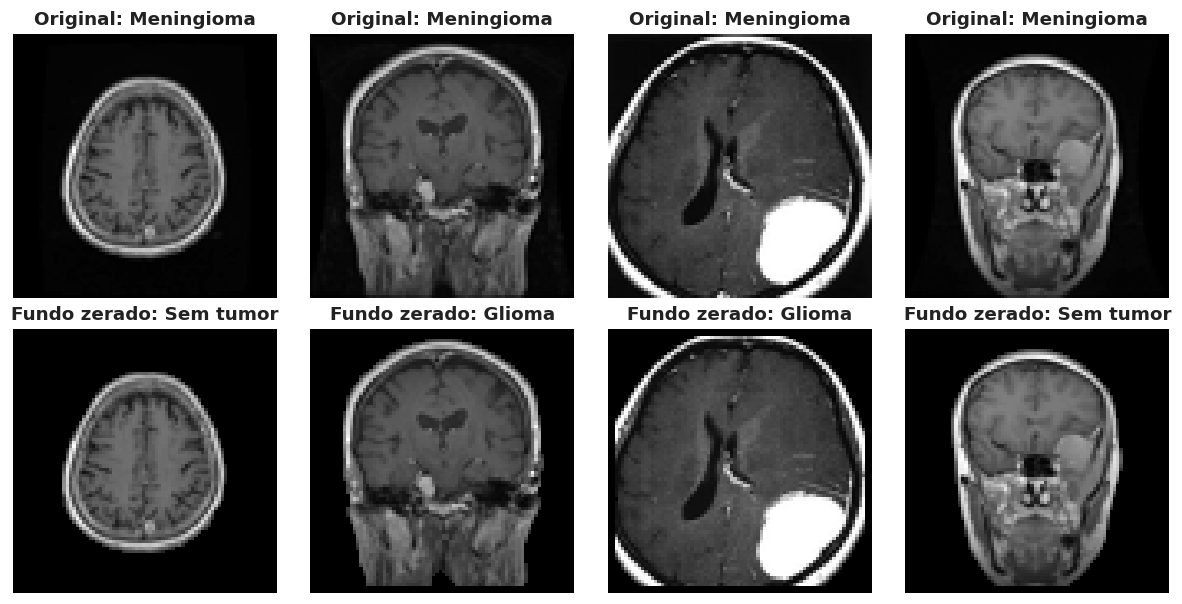

In [ ]:
flip = np.where((y_test == 1) & (p_orig == 1) & (p_masc != 1))[0]
print(len(flip), "meningiomas certos no original e errados com o fundo zerado")

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for j, i in enumerate(flip[:4]):
    axes[0, j].imshow(x_test[i, ..., 0], cmap="gray")
    axes[0, j].set_title("Original: Meningioma")
    axes[1, j].imshow(x_test_masc[i, ..., 0], cmap="gray")
    axes[1, j].set_title(f"Fundo zerado: {nomes[p_masc[i]]}")
for a in axes.flat:
    a.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
for t in [5, 10, 15, 25]:
    xm = np.where(x_test <= t, 0, x_test).astype("uint8")
    p = model.predict(xm, verbose=0).argmax(1)
    print(f"zerando pixels <= {t}: acurácia {(p == y_test).mean():.1%} | previsões que mudaram: {(p != p_orig).sum()}")

zerando pixels <= 5: acurácia 82.8% | previsões que mudaram: 25
zerando pixels <= 10: acurácia 79.9% | previsões que mudaram: 44
zerando pixels <= 15: acurácia 78.2% | previsões que mudaram: 56
zerando pixels <= 25: acurácia 72.5% | previsões que mudaram: 84


In [ ]:
DEMO_DIR = Path("demo_images")
DEMO_DIR.mkdir(exist_ok=True)

escolhidos =IDX_GLIOMA, IDX_MENINGIOMA, IDX_SEM_TUMOR, IDX_PITUITARIA = 57, 12, 301, 88  # exemplo: troque pelos seus  # troque pelos índices que você escolheu
gabarito = {}
for n, i in enumerate(escolhidos, 1):
    nome = f"caso_{n}.png"                      # nome neutro, para não entregar a resposta
    Image.fromarray(x_test[i, ..., 0]).save(DEMO_DIR / nome)
    gabarito[nome] = class_names[y_test[i]]

with open(DEMO_DIR / "gabarito.json", "w") as f:
    json.dump(gabarito, f, indent=2)

## 12. Conclusão 🎉

Chegamos ao fim! Em resumo, o que fizemos:

1. **Carregamos** ressonâncias magnéticas de quatro classes e as padronizamos (tons de cinza, 80 x 80).
2. **Limpamos** o dataset: descobrimos que boa parte das imagens de "teste" já estava no treino e removemos repetições exatas e quase-duplicatas.
3. **Dividimos por grupos**, para que imagens muito parecidas nunca ficassem em lados opostos da prova.
4. **Treinamos uma CNN** com aumento de dados, guardando a melhor versão pela validação.
5. **Avaliamos com honestidade**: métricas por classe, matriz de confusão e ROC no conjunto de teste, que só foi usado no final.
6. **Abrimos a caixa-preta** com o Grad-CAM e testamos a robustez do modelo.

**A principal lição:** um número de acurácia só vale o que o processo por trás dele vale. Limpar e dividir bem os dados mudou o que o resultado significa, e investigar onde o modelo erra ensinou mais do que o próprio treino.

> Lembrete: este é um projeto **educacional**, e não uma ferramenta de diagnóstico.

**Obrigado por acompanhar, e bora para as perguntas!**

In [ ]:
idx_sem = class_names.index("no_tumor")

acc = accuracy_score(y_test, pred_test)
f1m = f1_score(y_test, pred_test, average="macro")
rec = recall_score(y_test, pred_test, average=None)

eh_tumor = y_test != idx_sem
perdidos = int(((pred_test == idx_sem) & eh_tumor).sum())   # tumores classificados como "sem tumor"
n_tumores = int(eh_tumor.sum())

barras = ""
for nome, cor, r in zip(nomes, cores, rec):
    barras += (
        f'<div style="margin:6px 0;font-size:14px;">{nome} <b>{r:.0%}</b></div>'
        f'<div style="background:#ffffff22;border-radius:6px;height:10px;">'
        f'<div style="width:{r * 100:.0f}%;background:{cor};height:10px;border-radius:6px;"></div></div>'
    )

display(HTML(f"""
<div style="background:linear-gradient(135deg,#0F1115,#1c2530);color:#f2f2f2;
            padding:28px 32px;border-radius:16px;max-width:1000px;
            font-family:system-ui,sans-serif;">
  <div style="font-size:30px;font-weight:700;">🎉 Missão cumprida!</div>
  <div style="opacity:.8;margin:6px 0 20px;">Classificação de tumores cerebrais com uma CNN</div>

  <div style="display:flex;gap:28px;margin-bottom:18px;">
    <div><div style="font-size:34px;font-weight:700;color:#2A9D8F;">{acc:.1%}</div>
         <div style="opacity:.75;font-size:13px;">acurácia no teste</div></div>
    <div><div style="font-size:34px;font-weight:700;color:#E9C46A;">{f1m:.2f}</div>
         <div style="opacity:.75;font-size:13px;">F1 médio</div></div>
    <div><div style="font-size:34px;font-weight:700;color:#E76F51;">{perdidos}/{n_tumores}</div>
         <div style="opacity:.75;font-size:13px;">tumores vistos como "sem tumor"</div></div>
  </div>

  <div style="opacity:.75;font-size:13px;margin-bottom:4px;">Recall por classe</div>
  {barras}

  <div style="margin-top:22px;opacity:.7;font-size:12px;">
    Projeto educacional, não é uma ferramenta de diagnóstico.
  </div>
</div>
"""))